### 数据来源：https://www.kaggle.com/datasets/kartikeybartwal/ecommerce-product-recommendation-collaborative?resource=download

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 数据读取

In [2]:
user_data = pd.read_excel('D:/Users/王冰茵/PycharmProjects/pythonProject/new_text_3.15/data/user_personalized_features.xlsx')
user_data

,Unnamed: 0,User_ID,Age,Gender,Location,Income,Interests,Last_Login_Days_Ago,Purchase_Frequency,Average_Order_Value,Total_Spending,Product_Category_Preference,Time_Spent_on_Site_Minutes,Pages_Viewed,Newsletter_Subscription
0,0,#1,56,Male,Suburban,38037,Sports,5,7,18,2546,Books,584,38,True
1,1,#2,46,Female,Rural,103986,Technology,15,7,118,320,Electronics,432,40,False
2,2,#3,32,Female,Suburban,101942,Sports,28,1,146,3766,Apparel,306,1,True
3,3,#4,60,Female,Suburban,71612,Fashion,18,3,163,4377,Apparel,527,29,False
4,4,#5,25,Male,Suburban,49725,Travel,2,5,141,4502,Health & Beauty,53,10,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,995,#996,22,Male,Urban,104162,Technology,18,7,83,607,Apparel,542,21,False
996,996,#997,40,Male,Urban,99003,Travel,16,3,180,431,Apparel,359,4,True
997,997,#998,27,Female,Urban,72395,Technology,8,8,130,650,Books,331,34,False
998,998,#999,61,Male,Rural,59758,Travel,1,3,152,1041,Electronics,427,28,True


# 数据查看

In [3]:
user_data.info()
user_data.shape
user_data.head()
user_data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Unnamed: 0                   1000 non-null   int64 
 1   User_ID                      1000 non-null   object
 2   Age                          1000 non-null   int64 
 3   Gender                       1000 non-null   object
 4   Location                     1000 non-null   object
 5   Income                       1000 non-null   int64 
 6   Interests                    1000 non-null   object
 7   Last_Login_Days_Ago          1000 non-null   int64 
 8   Purchase_Frequency           1000 non-null   int64 
 9   Average_Order_Value          1000 non-null   int64 
 10  Total_Spending               1000 non-null   int64 
 11  Product_Category_Preference  1000 non-null   object
 12  Time_Spent_on_Site_Minutes   1000 non-null   int64 
 13  Pages_Viewed                 1000 

,Unnamed: 0,Age,Income,Last_Login_Days_Ago,Purchase_Frequency,Average_Order_Value,Total_Spending,Time_Spent_on_Site_Minutes,Pages_Viewed
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,499.500000,40.986000,81304.732000,15.586000,4.631000,104.039000,2552.957000,297.360000,24.40300
std,288.819436,13.497852,37363.972753,8.205604,2.837762,54.873569,1420.985048,175.596123,14.02017
min,0.000000,18.000000,20155.000000,1.000000,0.000000,10.000000,112.000000,2.000000,1.00000
25%,249.750000,29.000000,48715.500000,8.000000,2.000000,58.000000,1271.750000,144.000000,12.00000
50%,499.500000,42.000000,81042.000000,16.000000,5.000000,105.000000,2542.000000,292.500000,24.50000
75%,749.250000,52.000000,112694.500000,23.000000,7.000000,150.000000,3835.500000,449.250000,36.00000
max,999.000000,64.000000,149951.000000,29.000000,9.000000,199.000000,4999.000000,599.000000,49.00000


# 数据清洗

In [4]:
#缺失值的处理
user_data.isnull().sum()
user_data.dropna()
#重复值的处理
user_data.duplicated()
user_data.drop_duplicates()

,Unnamed: 0,User_ID,Age,Gender,Location,Income,Interests,Last_Login_Days_Ago,Purchase_Frequency,Average_Order_Value,Total_Spending,Product_Category_Preference,Time_Spent_on_Site_Minutes,Pages_Viewed,Newsletter_Subscription
0,0,#1,56,Male,Suburban,38037,Sports,5,7,18,2546,Books,584,38,True
1,1,#2,46,Female,Rural,103986,Technology,15,7,118,320,Electronics,432,40,False
2,2,#3,32,Female,Suburban,101942,Sports,28,1,146,3766,Apparel,306,1,True
3,3,#4,60,Female,Suburban,71612,Fashion,18,3,163,4377,Apparel,527,29,False
4,4,#5,25,Male,Suburban,49725,Travel,2,5,141,4502,Health & Beauty,53,10,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,995,#996,22,Male,Urban,104162,Technology,18,7,83,607,Apparel,542,21,False
996,996,#997,40,Male,Urban,99003,Travel,16,3,180,431,Apparel,359,4,True
997,997,#998,27,Female,Urban,72395,Technology,8,8,130,650,Books,331,34,False
998,998,#999,61,Male,Rural,59758,Travel,1,3,152,1041,Electronics,427,28,True


# 传统的RFM模型

In [16]:
user_data['r_level'] = pd.qcut(user_data['Last_Login_Days_Ago'].rank(method='first'),q=5,labels=[5,4,3,2,1])
user_data['f_level'] = pd.qcut(user_data['Purchase_Frequency'].rank(method='first'),q=5,labels=[1,2,3,4,5])
user_data['m_level'] = pd.qcut(user_data['Total_Spending'].rank(method='first'),q=5,labels=[1,2,3,4,5])
def judge(row):
    high_r = row['r_level'] >= 4
    high_f = row['f_level'] >= 4
    high_m = row['m_level'] >= 4
    if high_r and high_f and high_m:
        return '重要价值型'
    elif high_r and not high_f and high_m:
        return '重要发展型'
    elif not high_r and  high_f and high_m:
        return '重要保持型'
    elif not high_r and not high_f and high_m:
        return '重要挽留型'
    elif high_r and  high_f and not high_m:
        return '一般价值型'
    elif high_r and not high_f and not high_m:
        return '一般发展型'
    elif not high_r and high_f and not high_m:
        return '一般保持型'
    else:
        return '流失型'
user_data['rfm_type'] = user_data.apply(judge, axis=1)
user_data

,Unnamed: 0,User_ID,Age,Gender,Location,Income,Interests,Last_Login_Days_Ago,Purchase_Frequency,Average_Order_Value,...,Newsletter_Subscription,r_level,f_level,m_level,rfm_type,spending_type,Income_type,Engagement,Engagement_level,rfm_I_type
0,0,#1,56,Male,Suburban,38037,Sports,5,7,18,...,True,5,4,3,一般价值型,中高消费,高收入,155.87,高参与度,一般价值型
1,1,#2,46,Female,Rural,103986,Technology,15,7,118,...,False,3,4,1,一般保持型,低消费,低收入,118.06,高参与度,一般保持型
2,2,#3,32,Female,Suburban,101942,Sports,28,1,146,...,True,1,1,4,重要挽留型,中高消费,低收入,76.98,中参与度,重要挽留型
3,3,#4,60,Female,Suburban,71612,Fashion,18,3,163,...,False,3,2,5,重要挽留型,高消费,中收入,139.05,高参与度,重要挽留型
4,4,#5,25,Male,Suburban,49725,Travel,2,5,141,...,True,5,3,5,重要发展型,高消费,高收入,16.28,低参与度,重要发展型
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,995,#996,22,Male,Urban,104162,Technology,18,7,83,...,False,2,4,1,一般保持型,低消费,低收入,140.80,高参与度,一般保持型
996,996,#997,40,Male,Urban,99003,Travel,16,3,180,...,True,3,2,1,流失型,低消费,中收入,91.01,中参与度,普通发展型
997,997,#998,27,Female,Urban,72395,Technology,8,8,130,...,False,4,5,1,一般价值型,低消费,中收入,91.36,中参与度,一般价值型
998,998,#999,61,Male,Rural,59758,Travel,1,3,152,...,True,5,2,1,一般发展型,低消费,中收入,114.45,高参与度,潜力浏览型


# 传统RFM模型中存在的问题发现
##  1.存在高转化潜力的低消费土豪因为购买频次低以及购买总价低被误判为一般价值用户或者更低等级

In [6]:
Spending = [0,1271,2542,3835,5000]
user_data['spending_type'] = pd.cut(user_data['Total_Spending'],bins=Spending,labels=['低消费','中低消费','中高消费','高消费'])
user_data['Income_type'] = pd.qcut(user_data['Income'],q=3,labels=['高收入','中收入','低收入'])
error_type_1 = user_data[(user_data['spending_type']=='低消费') & (user_data['Income_type']=='高收入')].copy()
error_type_1['special_type'] = '低消费土豪'
error_type_1

,Unnamed: 0,User_ID,Age,Gender,Location,Income,Interests,Last_Login_Days_Ago,Purchase_Frequency,Average_Order_Value,...,Time_Spent_on_Site_Minutes,Pages_Viewed,Newsletter_Subscription,r_level,f_level,m_level,rfm_type,spending_type,Income_type,special_type
16,16,#17,39,Female,Rural,42656,Food,24,8,11,...,178,26,False,2,4,1,一般保持型,低消费,高收入,低消费土豪
32,32,#33,33,Male,Rural,56735,Travel,29,1,108,...,414,19,True,1,1,1,流失型,低消费,高收入,低消费土豪
36,36,#37,20,Female,Rural,45498,Food,28,6,129,...,128,19,True,1,3,1,流失型,低消费,高收入,低消费土豪
46,46,#47,26,Female,Suburban,39033,Technology,4,4,32,...,144,37,False,5,2,1,一般发展型,低消费,高收入,低消费土豪
50,50,#51,45,Male,Urban,46832,Food,12,3,94,...,85,26,False,4,2,1,一般发展型,低消费,高收入,低消费土豪
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
959,959,#960,28,Female,Rural,22282,Technology,24,2,168,...,511,48,True,1,2,1,流失型,低消费,高收入,低消费土豪
960,960,#961,21,Female,Urban,54624,Fashion,6,0,62,...,581,44,False,5,1,1,一般发展型,低消费,高收入,低消费土豪
975,975,#976,21,Female,Suburban,27461,Fashion,13,9,108,...,47,14,False,3,5,1,一般保持型,低消费,高收入,低消费土豪
977,977,#978,37,Female,Urban,30516,Food,26,0,86,...,427,43,False,1,1,1,流失型,低消费,高收入,低消费土豪


## 2.存在高浏览量停留时长较长的高潜力用户因为购买频次少且消费较低被分为一般发展用户或者更低等级

In [7]:
error_type_2 = user_data[(user_data['Time_Spent_on_Site_Minutes'] > user_data['Time_Spent_on_Site_Minutes'].median()) & (user_data['Pages_Viewed'] > user_data['Pages_Viewed'].median())].copy()
error_type_2 = error_type_2[error_type_2['rfm_type'].isin(['一般价值客户','一般保持客户','一般发展客户','流失客户']) ].copy()
error_type_2['spending_type'] = '高潜力用户误判'
error_type_2

,Unnamed: 0,User_ID,Age,Gender,Location,Income,Interests,Last_Login_Days_Ago,Purchase_Frequency,Average_Order_Value,...,Product_Category_Preference,Time_Spent_on_Site_Minutes,Pages_Viewed,Newsletter_Subscription,r_level,f_level,m_level,rfm_type,spending_type,Income_type


## 3.忠诚用户误判--该案例无错误
### 该错误主要为传统RFM模型判断不出用户行为背后的价值意义，对于高收入与低收入用户，消费同样高价位的商品背后的价值意义是不同的，对于高收入用户只是日常开销，而对于低收入人群则体现了用户对平台的信任与忠诚，但传统的RFM模型会将同消费的用户分为一个分层，这就体现不出其背后的价值意义，在策略运用上可能会出现偏差导致客户的流失

In [8]:
same_spending_range = user_data[(user_data['Total_Spending'] >= 3000) & (user_data['Total_Spending'] <= 5000)]

# 3. 对比不同收入组的RFM得分
same_spending_range[(same_spending_range['spending_type'] == '高消费') & (same_spending_range['Income_type'] == '低收入')]
same_spending_range

,Unnamed: 0,User_ID,Age,Gender,Location,Income,Interests,Last_Login_Days_Ago,Purchase_Frequency,Average_Order_Value,...,Product_Category_Preference,Time_Spent_on_Site_Minutes,Pages_Viewed,Newsletter_Subscription,r_level,f_level,m_level,rfm_type,spending_type,Income_type
9,9,#10,28,Male,Urban,121604,Food,13,8,61,...,Electronics,114,36,False,4,4,5,重要价值型,高消费,低收入
14,14,#15,41,Male,Urban,122031,Travel,11,5,155,...,Electronics,299,43,False,4,3,5,重要发展型,高消费,低收入
18,18,#19,41,Male,Rural,111396,Travel,28,3,22,...,Health & Beauty,154,36,False,1,2,5,重要挽留型,高消费,低收入
26,26,#27,39,Female,Urban,115081,Fashion,25,9,17,...,Electronics,359,27,True,1,5,5,重要保持型,高消费,低收入
58,58,#59,34,Male,Rural,137322,Travel,29,3,192,...,Home & Kitchen,378,22,False,1,2,5,重要挽留型,高消费,低收入
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
910,910,#911,42,Female,Urban,117938,Fashion,25,8,86,...,Books,576,22,False,1,5,4,重要保持型,高消费,低收入
915,915,#916,62,Male,Urban,115344,Technology,1,2,97,...,Apparel,33,3,False,5,2,5,重要发展型,高消费,低收入
955,955,#956,23,Male,Rural,138696,Sports,27,1,198,...,Health & Beauty,41,17,False,1,1,5,重要挽留型,高消费,低收入
962,962,#963,23,Female,Rural,109900,Technology,2,8,162,...,Books,81,27,False,5,5,5,重要价值型,高消费,低收入


## 将两种误判结果进行合并

In [21]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

error_type = pd.concat([error_type_1, error_type_2], axis=0, ignore_index=True)
num = error_type.groupby('User_ID',as_index=False)['User_ID'].value_counts()
pie = len(num)/len(user_data)
pie

0.073

### 一共有205个用户存在误判情况，总共1000条数据，占整体的20%

In [10]:
user_data

,Unnamed: 0,User_ID,Age,Gender,Location,Income,Interests,Last_Login_Days_Ago,Purchase_Frequency,Average_Order_Value,...,Product_Category_Preference,Time_Spent_on_Site_Minutes,Pages_Viewed,Newsletter_Subscription,r_level,f_level,m_level,rfm_type,spending_type,Income_type
0,0,#1,56,Male,Suburban,38037,Sports,5,7,18,...,Books,584,38,True,5,4,3,一般价值型,中高消费,高收入
1,1,#2,46,Female,Rural,103986,Technology,15,7,118,...,Electronics,432,40,False,3,4,1,一般保持型,低消费,低收入
2,2,#3,32,Female,Suburban,101942,Sports,28,1,146,...,Apparel,306,1,True,1,1,4,重要挽留型,中高消费,低收入
3,3,#4,60,Female,Suburban,71612,Fashion,18,3,163,...,Apparel,527,29,False,3,2,5,重要挽留型,高消费,中收入
4,4,#5,25,Male,Suburban,49725,Travel,2,5,141,...,Health & Beauty,53,10,True,5,3,5,重要发展型,高消费,高收入
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,995,#996,22,Male,Urban,104162,Technology,18,7,83,...,Apparel,542,21,False,2,4,1,一般保持型,低消费,低收入
996,996,#997,40,Male,Urban,99003,Travel,16,3,180,...,Apparel,359,4,True,3,2,1,流失型,低消费,中收入
997,997,#998,27,Female,Urban,72395,Technology,8,8,130,...,Books,331,34,False,4,5,1,一般价值型,低消费,中收入
998,998,#999,61,Male,Rural,59758,Travel,1,3,152,...,Electronics,427,28,True,5,2,1,一般发展型,低消费,中收入


# RFM模型的更新--防止出现低消费土豪问题、高潜力用户误判以及忠诚用户误判问题（该案例无出现，仅为其他理论补充）
## 1.针对低消费土豪、忠诚用户误判问题，在传统的RFM模型的基础上，添加收入类型与参与度指标，综合进行判断
## 2.针对高潜力用户误判低价值用户问题，在传统的RFM模型的基础上，添加参与度指标进行综合判断

In [11]:
#收入类型指标之前已经建立好，现在建立参与度指标
#参与度 = login_active(1/Last_Login_Days_Ago+1) *0.3 + Pages_Viewed * 0.25 + Time_Spent_on_Site_Minutes * 0.25 + Newsletter_Subscription * 0.2
def judge(row):
    login_min_time = 1/(row['Last_Login_Days_Ago']+1)
    pages_viewed = row['Pages_Viewed'] * 0.25
    time_spend = row['Time_Spent_on_Site_Minutes'] * 0.25
    news = row['Newsletter_Subscription']
    if news :
        Engagement = login_min_time + pages_viewed + time_spend + 0.2
        return Engagement
    elif not news :
        Engagement = login_min_time + pages_viewed + time_spend
        return Engagement
    else:
        return '状态错误'
user_data['Engagement'] = user_data.apply(judge, axis=1)
user_data['Engagement'] = user_data['Engagement'].round(2)
user_data['Engagement_level'] = pd.qcut(user_data['Engagement'],q=3,labels=['低参与度','中参与度','高参与度'])

### 根据新的标准进行用户的角色画像分层
### 将用户分为潜力浏览型、土豪休眠型、忠诚死忠型、价值标杆型、普通发展型、流失风险型，部分用户是那些没有明显极端特征的普通用户，利用原来的rfm模型分层

In [28]:
def person_view(row):
    high_r = row['r_level'] >= 4
    high_f = row['f_level'] >= 4
    high_m = row['m_level'] >= 4
    Engagement = row['Engagement_level']
    income_level = row['Income_type']
    if high_f and high_m and Engagement == '高参与度' and income_level == '低收入':
        return '忠诚死忠型'
    elif not high_f and not high_m and Engagement == '高参与度':
        return '潜力浏览型'
    elif not high_f and not high_m and (Engagement == '中参与度' or Engagement == '低参与度') and income_level == '高收入':
        return '土豪休眠型'
    return row['rfm_type']

user_data['rfm_I_type'] = user_data.apply(person_view, axis=1)
# len(user_data)


In [29]:
user_data

,Unnamed: 0,User_ID,Age,Gender,Location,Income,Interests,Last_Login_Days_Ago,Purchase_Frequency,Average_Order_Value,...,Newsletter_Subscription,r_level,f_level,m_level,rfm_type,spending_type,Income_type,Engagement,Engagement_level,rfm_I_type
0,0,#1,56,Male,Suburban,38037,Sports,5,7,18,...,True,5,4,3,一般价值型,中高消费,高收入,155.87,高参与度,一般价值型
1,1,#2,46,Female,Rural,103986,Technology,15,7,118,...,False,3,4,1,一般保持型,低消费,低收入,118.06,高参与度,一般保持型
2,2,#3,32,Female,Suburban,101942,Sports,28,1,146,...,True,1,1,4,重要挽留型,中高消费,低收入,76.98,中参与度,重要挽留型
3,3,#4,60,Female,Suburban,71612,Fashion,18,3,163,...,False,3,2,5,重要挽留型,高消费,中收入,139.05,高参与度,重要挽留型
4,4,#5,25,Male,Suburban,49725,Travel,2,5,141,...,True,5,3,5,重要发展型,高消费,高收入,16.28,低参与度,重要发展型
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,995,#996,22,Male,Urban,104162,Technology,18,7,83,...,False,2,4,1,一般保持型,低消费,低收入,140.80,高参与度,一般保持型
996,996,#997,40,Male,Urban,99003,Travel,16,3,180,...,True,3,2,1,流失型,低消费,中收入,91.01,中参与度,流失型
997,997,#998,27,Female,Urban,72395,Technology,8,8,130,...,False,4,5,1,一般价值型,低消费,中收入,91.36,中参与度,一般价值型
998,998,#999,61,Male,Rural,59758,Travel,1,3,152,...,True,5,2,1,一般发展型,低消费,中收入,114.45,高参与度,潜力浏览型


# 数据可视化

Text(1059.4267676767674, 0.5, '数值')

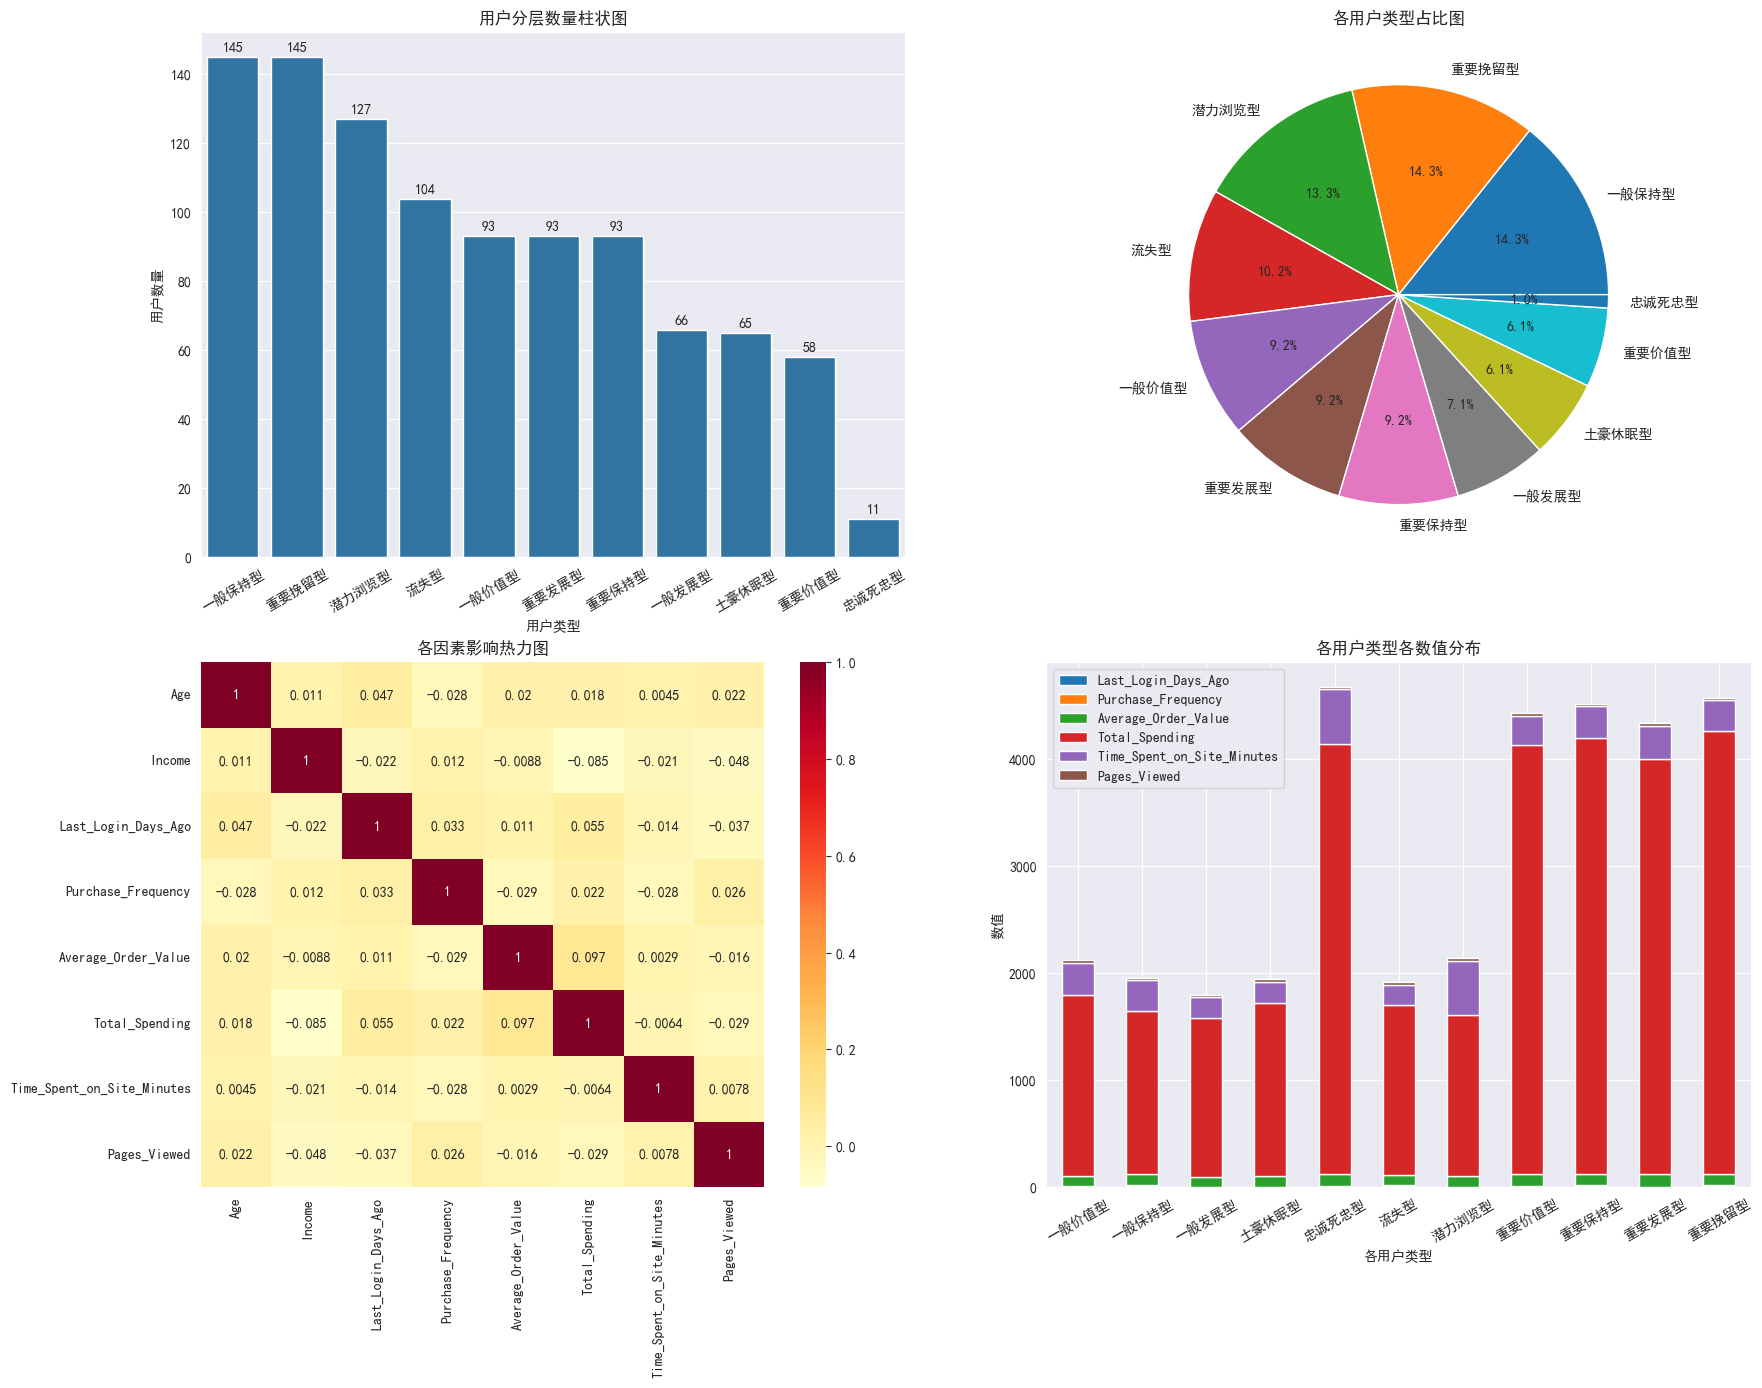

In [30]:
fig,ax = plt.subplots(2,2,figsize = (20,15))
#各用户分层的数量柱状图
user_type = user_data.groupby('rfm_I_type',as_index=False).agg({'User_ID':'count','Total_Spending':'mean','Last_Login_Days_Ago':'min','Time_Spent_on_Site_Minutes':'mean'}).sort_values('User_ID',ascending=False)
user_type.columns = ['rfm_I_type','ID_count','Total_Spending_mean','Last_Login_Days_Ago','Time_Spent_on_Site_Minutes']
sns.barplot(data=user_type,x='rfm_I_type',y='ID_count',ax=ax[0,0])
ax[0,0].set_title('用户分层数量柱状图')
ax[0,0].set_xlabel('用户类型')
ax[0,0].set_ylabel('用户数量')
ax[0,0].tick_params(axis='x', rotation=30)
for x,y in zip(user_type['rfm_I_type'],user_type['ID_count']):
    ax[0,0].text(x,y+1,y,va='bottom',ha='center')

#各用户类型占比
user_type['pie'] = round(user_type['ID_count']/len(user_data),2)
ax[0,1].pie(user_type['pie'],labels=user_type['rfm_I_type'],autopct='%1.1f%%')
ax[0,1].set_title('各用户类型占比图')

#各因素相关系数热力图
columns = ['Age','Income','Last_Login_Days_Ago','Purchase_Frequency','Average_Order_Value','Total_Spending','Time_Spent_on_Site_Minutes','Pages_Viewed']
corr = user_data[columns].corr()
sns.heatmap(data=corr,annot=True,cmap='YlOrRd',ax=ax[1,0])
ax[1,0].set_title('各因素影响热力图')

#
user_df = user_data.groupby('rfm_I_type',as_index=False).agg(Last_Login_Days_Ago=('Last_Login_Days_Ago','min'),Purchase_Frequency=('Purchase_Frequency','mean'),Average_Order_Value=('Average_Order_Value','mean'),Total_Spending=('Total_Spending','mean'),Time_Spent_on_Site_Minutes=('Time_Spent_on_Site_Minutes','mean'),Pages_Viewed=('Pages_Viewed','mean')).round(2)
user_df.set_index('rfm_I_type').plot.bar(stacked=True, ax=ax[1, 1])
ax[1, 1].tick_params(axis='x', rotation=30)
ax[1,1].set_title('各用户类型各数值分布')
ax[1,1].set_xlabel('各用户类型')
ax[1,1].set_ylabel('数值')

**针对平台的GMV增长的核心问题，根据皮尔逊相关系数分析可得：**

**收入越高的人，消费反而略低。这恰好验证了之前提出的“低消费土豪”问题——高收入用户并没有在平台上高消费，说明他们的消费潜力尚未被挖掘。**

**浏览时长/页数与消费金额几乎无关。这正好验证了“高活跃浏览但不购买”问题——有些人逛了很久但不花钱，他们不是低价值用户，而是待转化的潜力用户。**

**高频购买的用户不一定客单价高，两者几乎独立。这意味着平台可以同时从“提频”和“提客单”两个方向发力，互不干扰。**

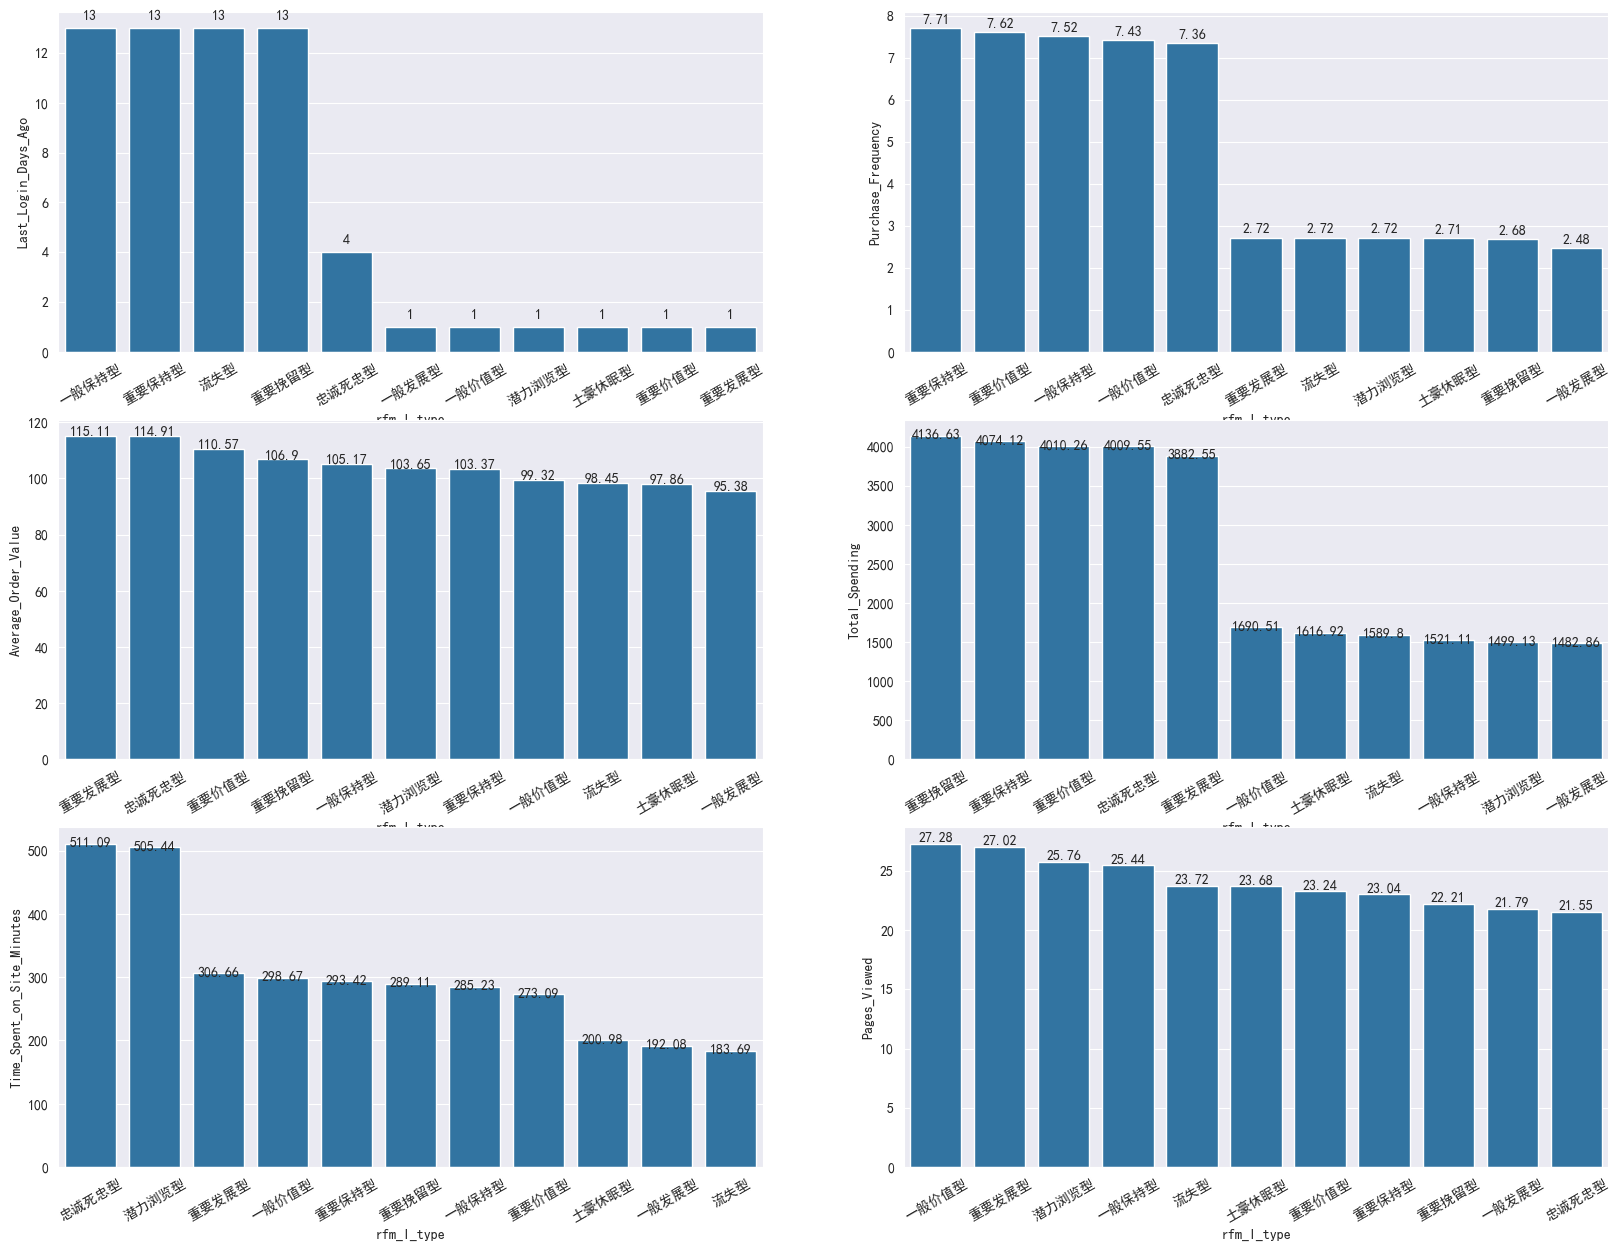

In [31]:
fig ,ax = plt.subplots(3,2,figsize=(20,15))
sns.barplot(data=user_df,
            x='rfm_I_type',
            y='Last_Login_Days_Ago',
            order=user_df.groupby('rfm_I_type')['Last_Login_Days_Ago'].mean().sort_values(ascending=False).index,
            ax=ax[0,0])
ax[0,0].tick_params(axis='x', rotation=30)
for x,y in zip(user_df['rfm_I_type'],user_df['Last_Login_Days_Ago']):
    ax[0,0].text(x,y+0.5,y,va='center',ha='center')

sns.barplot(data=user_df,
            x='rfm_I_type',
            y='Purchase_Frequency',
            order=user_df.groupby('rfm_I_type')['Purchase_Frequency'].mean().sort_values(ascending=False).index,
            ax=ax[0,1])
ax[0,1].tick_params(axis='x', rotation=30)
for x,y in zip(user_df['rfm_I_type'],user_df['Purchase_Frequency']):
    ax[0,1].text(x,y+0.2,y,va='center',ha='center')

sns.barplot(data=user_df,
            x='rfm_I_type',
            y='Average_Order_Value',
            order=user_df.groupby('rfm_I_type')['Average_Order_Value'].mean().sort_values(ascending=False).index,
            ax=ax[1,0])
ax[1,0].tick_params(axis='x', rotation=30)
for x,y in zip(user_df['rfm_I_type'],user_df['Average_Order_Value']):
    ax[1,0].text(x,y+1.5,y,va='center',ha='center')

sns.barplot(data=user_df,
            x='rfm_I_type',
            y='Total_Spending',
            order=user_df.groupby('rfm_I_type')['Total_Spending'].mean().sort_values(ascending=False).index,
            ax=ax[1,1])
ax[1,1].tick_params(axis='x', rotation=30)
for x,y in zip(user_df['rfm_I_type'],user_df['Total_Spending']):
    ax[1,1].text(x,y+10,y,va='center',ha='center')

sns.barplot(data=user_df,
            x='rfm_I_type',
            y='Time_Spent_on_Site_Minutes',
            order=user_df.groupby('rfm_I_type')['Time_Spent_on_Site_Minutes'].mean().sort_values(ascending=False).index,
            ax=ax[2,0])
ax[2,0].tick_params(axis='x', rotation=30)
for x,y in zip(user_df['rfm_I_type'],user_df['Time_Spent_on_Site_Minutes']):
    ax[2,0].text(x,y+1.5,y,va='center',ha='center')

sns.barplot(data=user_df,
            x='rfm_I_type',
            y='Pages_Viewed',
            order=user_df.groupby('rfm_I_type')['Pages_Viewed'].mean().sort_values(ascending=False).index,
            ax=ax[2,1])
ax[2,1].tick_params(axis='x', rotation=30)
for x,y in zip(user_df['rfm_I_type'],user_df['Pages_Viewed']):
    ax[2,1].text(x,y+0.5,y,va='center',ha='center')

**关键洞察：**

土豪休眠型（65人） 人均收入较高，但购买频次与购买总金额普遍较低，浏览时长和页面访问量也偏低，用户的消费潜力完全没有被激活，属于典型的沉睡高价值用户。

潜力浏览型（127人） 是新模型最重要的发现！他们浏览时长高达505分钟（远超一般用户的150-300分钟），但消费只有1500元左右。这批用户如果转化成功，价值空间巨大。

忠诚死忠型（11人）的用户消费频次较高、总消费平均值高达4000，是平台的重要保持对象，需要进行及时维护。

各个分层的用户的客单价相差不大，消费的差异主要体现在用户的购买频次

**（1）潜力浏览型（127人，占比12.7%）—— 核心潜力用户**

**特征：**
- 浏览时长极高（505分钟，远超均值）
- 页面浏览数高
- 消费金额较低（约1500元）
- 购买频率偏低

**策略建议**

- 重点转化高活跃浏览用户
- 推送“今日首单优惠券”、“新人专享价”
- 弹出“限时折扣”、“限时包邮”提示
- 根据浏览记录推送“你可能喜欢的商品”
- 设置“加购未支付”提醒 + 小额优惠券

---

**（2）土豪休眠型（65人，占比6.5%）—— 核心潜力用户**

**特征：**
- 浏览时长中等
- 收入水平较高
- 消费金额较低（约1600元）
- 购买频率偏低

**策略建议**

- 推送高端商品、限量款、设计师款、奢侈品牌，满足高收入人群的品质需求
- 可推送“高端会员专享价”、“VIP折扣”
- 基于收入标签 + 兴趣标签，做个性化高端商品推荐（如奢侈品、高端电子产品、旅行套餐等）
- 推送“专属回归礼包” + “高端新品首发” + “VIP专属客服”
- 开通“黑卡会员”、“尊享服务”（如免费退换、专属客服、生日礼遇）

**（3）忠实死忠型（11人，占比1.1%）—— 核心潜力用户**

**特征：**
- 收入较低
- 消费金额较高，总消费平均值超4000
- 购买频率较高

**策略建议**

- 推送“感谢信”、周年纪念礼、用户故事征集
- 建立会员体系，给予高等级会员专属权益（折扣、免邮、生日礼）
- 推送“老用户专享价”、“满额返券”、“复购积分加倍”
- 设置“推荐有礼”机制，邀请好友得优惠券/积分
- 提供“限时折扣”、“拼团优惠”、“秒杀专区”

**其他类型的用户分层特征以及建议可以参考‘user_personalized_features_TEXT’，链接为：https://github.com/bingbing-0401/-RFM-/blob/main/user_personalized_features_TEXT.ipynb**
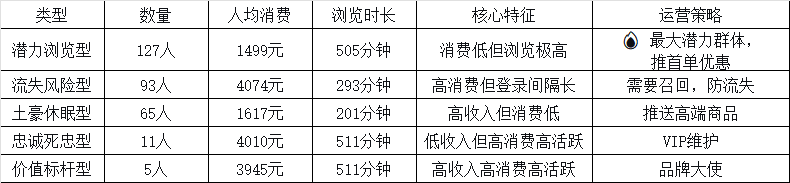